## Evaluation and minimization of the loss function

In [1]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from pH_refine import load_pH_data, pH_loss, pH_tilde_loss_and_grad, Lambdas

### 1. load data

load data from experiments and MD simulations

- load data after WHAM has been performed as described in `WHAM.ipynb`

`WHAM.ipynb` performs WHAM and returns:
- `WHAM_df.txt` (weights as output of WHAM, protonation numbers and observables from concatenated trajectories from multiple constant pH MD simulations)
- `WHAM_pops_3.98.txt` (populations of the protonation states indicated in columns at a reference pH chosen as the closest one to the pKa, namely, to 50/50 populations -- notice this value of the pH is not present in the original MD simulations, but it is very close to one of them)

In [3]:
from pH_refine import PHData, compute_pH_weights

##### input data
- weights, protonation numbers, observables (from `WHAM_df.txt`)
- populations at reference pH (from `WHAM_pops_3.98.txt`)
- values of pH `pH_vals`

In [4]:
my_df = pandas.read_csv('Simulation-data/A3mer/WHAM_df.txt', index_col=0)

my_df

,weight,n_prot,chi,eRMSD
0,7.853643e-06,1.0,-1.050246,1.054092
1,1.578589e-05,1.0,-1.043169,1.175289
2,2.126278e-07,1.0,-0.292339,1.103215
3,1.271614e-07,1.0,-0.155172,1.130084
4,5.902291e-08,1.0,-0.016830,1.108039
...,...,...,...,...
112495,1.273789e-05,1.0,-0.931121,1.180245
112496,6.969360e-07,1.0,-0.388632,1.166304
112497,5.355708e-06,1.0,-0.803565,1.224548
112498,2.534988e-06,1.0,-0.592147,1.194844


In [5]:
ref_pops = np.array(pandas.read_csv('Simulation-data/A3mer/WHAM_pops_3.98.txt', index_col=0))[0]
ref_pH = 3.98

ref_pops

array([0.51023236, 0.48976764])

In [6]:
pH_vals = [3.0, 3.5, 4.0]

##### load data
from the two files indicated above, you get:
- set of possible protonation numbers/states `ns_prot`
- observables split for each protonation state `gs`
- pH differences `delta_pH_vals` (and corresponding `log_fugacities`)
- average values (and associated errors) at fixed protonation state and at fixed pH (the latter are weighted averages of the first ones); they can be used to get synthetic experimental data
- populations of the two protonation states at reference pH (required to evaluate and minimize the loss) and at pH values in `pH_vals`
- canonical (normalized) weights for each protonation state

In [7]:
ns_prot = np.unique(my_df['n_prot']).astype(int)

ns_prot

array([0, 1])

In [8]:
my_obs = my_df[['chi', 'eRMSD']]

gs = {}

for n_prot in ns_prot:
    gs[n_prot] = np.array(my_obs[my_df['n_prot'] == n_prot])

In [9]:
delta_pH_vals = np.array(pH_vals) - ref_pH

log_fugacities = -np.array(delta_pH_vals)*np.log(10)

In [10]:
avs_prot = {}

for j in range(2):
    avs_prot[j] = np.dot(my_obs[my_df['n_prot'] == j].T, my_df['weight'][my_df['n_prot'] == j])/np.sum(my_df['weight'][my_df['n_prot'] == j])

avs_prot

{0: array([-0.51081261,  1.06871165]), 1: array([0.54940919, 1.22269712])}

In [11]:
avs = {}
stds = {}
kish = {}
errs = {}

for pH in pH_vals:
    logf = -pH*np.log(10)
    w = compute_pH_weights(np.log(np.array(my_df['weight'])), logf, np.array(my_df['n_prot']))
    avs[logf] = np.dot(my_obs.T, w)
    stds[logf] = np.sqrt(np.dot((my_obs**2).T, w) - avs[logf]**2)
    kish[logf] = np.sum(w**2)
    errs[logf] = stds[logf]*np.sqrt(kish[logf])

In [12]:
print('averages:\n', pandas.DataFrame(avs))
print('\nerrors on averages:\n', pandas.DataFrame(errs))
print('\nstds:\n', pandas.DataFrame(stds))

averages:
    -6.907755  -8.059048  -9.210340
0   0.445127   0.277476  -0.003744
1   1.207551   1.183202   1.142358

errors on averages:
    -6.907755  -8.059048  -9.210340
0   0.015258   0.014024   0.013469
1   0.001854   0.001833   0.001902

stds:
    -6.907755  -8.059048  -9.210340
0   1.575605   1.670041   1.782398
1   0.191443   0.218231   0.251736


- compare with populations of the two protonation states: the average values at a given pH are in between the two extreme cases of the averages at one or the other protonation state

In [13]:
pops = {}

for pH in pH_vals:
    logf = -(pH - ref_pH)*np.log(10)
    pops[pH] = compute_pH_weights(np.log(ref_pops), logf, np.array([0, 1]))

pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

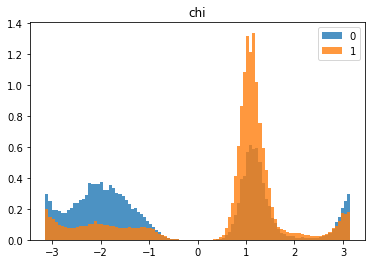

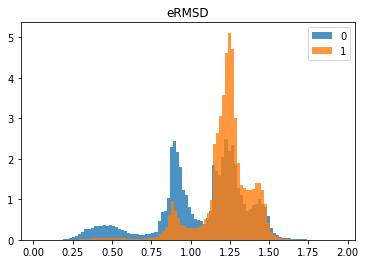

In [14]:
obs_names = ['chi', 'eRMSD']

for name in obs_names:
    plt.figure()
    plt.title(name)

    for i in range(2):
        plt.hist(my_df[name][my_df['n_prot'] == i], weights=my_df['weight'][my_df['n_prot'] == i],
                alpha=0.8, bins=100, label=i, density=True)

    plt.legend()

In [15]:
weights = {}

for n_prot in ns_prot:
    weights[n_prot] = np.array(my_df['weight'][my_df['n_prot'] == n_prot])
    weights[n_prot] /= np.sum(weights[n_prot])

weights

{0: array([4.42346099e-07, 1.18166257e-05, 1.02347386e-07, ...,
        4.79335366e-05, 2.67926326e-05, 1.36390210e-05]),
 1: array([7.85449964e-06, 1.57876092e-05, 2.12651042e-07, ...,
        6.97012053e-07, 5.35629209e-06, 2.53526442e-06])}

In [16]:
from pH_refine import ManageIndices

In [17]:
g_exp = ManageIndices.flatten(np.array(pandas.DataFrame(avs)))
sigma_exp = ManageIndices.flatten(np.array(pandas.DataFrame(errs)))

legend_matrix = ManageIndices.build_legend(np.array(pandas.DataFrame(avs)))[0]


In [18]:
data = PHData(g_exp, sigma_exp, legend_matrix, gs, weights, None, ref_pH, ref_pops, pops, log_fugacities, ns_prot, obs_names, pH_vals)

In [19]:
data.keys()

dict_keys(['g_exp', 'sigma_exp', 'legend_matrix', 'gs', 'p0s', 'legend_weights', 'ref_pH', 'ref_pops', 'pops', 'log_fugacities', 'ns_prot', 'obs_names', 'pH_vals'])

In [20]:
data.pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

### 2nd step: evaluate the loss function for the original `data`

In [21]:
pi_vec = data.ref_pops
lambdas_vec = np.zeros(len(data.g_exp))

out = pH_loss(lambdas=lambdas_vec, pis=pi_vec, data=data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 3rd step: minimize the loss function through `pH_tilde_loss`
(dimensionality reduction with `lambdas`)

In [22]:
log_pi_vec = np.log(pi_vec)


In [23]:
# is_fixed = False, so inner minimization of Gamma (required to compute the gradient)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)


loss, grad:  -1.1329434389867456e-16 [0. 0.]
pi_vec:  [0.51023236 0.48976764]




(Array(-1.13294344e-16, dtype=float64), Array([0., 0.], dtype=float64))

In [24]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)


loss, grad:  -1.1329434389867456e-16 [0. 0.]
pi_vec:  [0.51023236 0.48976764]




In [25]:
mini

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.1329434389867456e-16
        x: [-6.729e-01 -7.138e-01]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 1
     njev: 1

In [26]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.51023236, 0.48976764])

In [27]:
vars(lambdas)

{'value': array([0., 0., 0., 0., 0., 0.]), 'is_fixed': False}

### 4. evaluate `pH_loss` on the optimal solution
- do the values of the loss function agree?
- is this value lower than the starting one?

In [28]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

In [29]:
print(mini.fun, out.loss)

-1.1329434389867456e-16 7.693513204315125e-24


yes, they agree!

In [30]:
out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 5. modify synthetic "experimental" data
such that they do not match the original average values

In [31]:
print(g_exp)
print(data.sigma_exp*10)

[ 0.44512738  0.27747556 -0.00374353  1.20755134  1.18320177  1.14235782]
[0.15257762 0.14023983 0.13469085 0.01853883 0.01832573 0.01902298]


In [32]:
rescaling = 10
random_fact = np.random.normal(size=len(data.g_exp))
print(random_fact)

data.g_exp = g_exp + random_fact*data.sigma_exp*rescaling

data.g_exp

[ 0.79946918 -0.00306748  1.22230489  0.88012003 -0.35372112  1.06328247]


Array([0.56710848, 0.27704537, 0.16088975, 1.22386774, 1.17671958,
       1.16258462], dtype=float64)

In [33]:
lambdas = np.zeros(len(data.g_exp))
pH_loss(lambdas, pi_vec, data)

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(208.174456, dtype=float64)
        chi2: Array(416.348912, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(208.174456, dtype=float64)
    rel_diff: Array([[ -7.99469177,   0.03067478, -12.22304891],
                     [ -8.80120028,   3.5372112 , -10.63282467]], dtype=float64)

In [34]:
log_pi_vec = np.log(pi_vec)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)

loss, grad:  87.00085524251516 [-42.77001908  42.77001908]
pi_vec:  [0.51023236 0.48976764]




(Array(87.00085524, dtype=float64),
 Array([-42.77001908,  42.77001908], dtype=float64))

In [35]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)

loss, grad:  87.00085524251516 [-42.77001908  42.77001908]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  26.076766708968456 [-32.05871804  32.05871804]
pi_vec:  [0.81294958 0.18705042]


loss, grad:  223.62948171274604 [ 223.27576716 -223.27576716]
pi_vec:  [0.99507297 0.00492703]


loss, grad:  5.7739654882463745 [-7.96074735  7.96074735]
pi_vec:  [0.92695869 0.07304131]


loss, grad:  3.8367636990715175 [-3.18944591  3.18944591]
pi_vec:  [0.94759294 0.05240706]


loss, grad:  3.4085584461887573 [-0.4485642  0.4485642]
pi_vec:  [0.95817436 0.04182564]


loss, grad:  3.3998377672107867 [-0.00022693  0.00022693]
pi_vec:  [0.95969915 0.04030085]


loss, grad:  3.399837763597244 [-0.00014176  0.00014176]
pi_vec:  [0.95969991 0.04030009]


loss, grad:  3.3998377645539657 [ 0.0001264 -0.0001264]
pi_vec:  [0.95970117 0.04029883]


loss, grad:  3.399837762841745 [ 3.31642015e-05 -3.31642015e-05]
pi_vec:  [0.95970034 0.04029966]


loss, grad:  3.3998377627813636 [ 2.39659663e-05 -2.39659663e

In [36]:
mini

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 3.3998377627714773
        x: [ 8.918e-01 -2.278e+00]
      nit: 9
      jac: [-1.046e-06  1.046e-06]
 hess_inv: [[ 5.575e-01  4.425e-01]
            [ 4.425e-01  5.575e-01]]
     nfev: 12
     njev: 12

In [41]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.95970006, 0.04029994])

In [51]:
pKa = data.ref_pH - np.log10(pi_new[0]/pi_new[1])

print('optimal pKa: ', pKa)

optimal pKa:  2.603168829247597


In [52]:
logf = -(pKa - ref_pH)*np.log(10)
compute_pH_weights(np.log(pi_new), logf, np.array([0, 1]))


Array([0.5, 0.5], dtype=float64)

In [53]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[0.0959361 , 1.15105564],
                     [1.73521641, 1.40221252]], dtype=float64)
      avs_ph: Array([[0.56515653, 0.28042474, 0.15914031],
                     [1.22294569, 1.17932145, 1.16073926]], dtype=float64)
 check_gamma: Array(3.32277823e-05, dtype=float64)
        chi2: Array(3.2955252, dtype=float64)
       dkl_p: Array([0.0624071 , 1.18405876], dtype=float64)
      dkl_pi: Array(0.50564253, dtype=float64)
       gamma: Array(-2.89419523, dtype=float64)
      log_ps: [Array([-14.54699861, -11.23760337, -16.13266195, ..., -10.05303294,
                     -10.62467412, -11.20575217], dtype=float64), Array([-16.51906254, -14.57504696, -18.97610727, ..., -17.2261109 ,
                     -14.94672136, -15.8173446 ], dtype=float64)]
        loss: Array(3.39987099, dtype=float64)
    rel_diff: Array([[-0.12793169,  0.24097068, -0.12988569],
                     [-0.49736397,  1.41979472, -0.97006884]], dtype=float64)

In [54]:
print(out.loss, mini.fun)

if np.abs(out.loss - mini.fun) < 1e-3: print('yes, they agree!')
else: print('significant mismatch, possible errors!')

3.3998709905537927 3.3998377627714773
yes, they agree!


### 6. define `pH_minimizer` function

so, let's define a function that minimizes the loss through `pH_tilde_loss` and returns results of `pH_loss`

In [61]:
def pH_minimizer(data, alpha_pi = 1., alphas = 1.):
    
    lambdas = Lambdas(np.zeros(len(data.g_exp)), False)
    args = (data, lambdas, alpha_pi, alphas)

    mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)

    pi_new = np.exp(mini.x)
    pi_new /= np.sum(pi_new)

    out = pH_loss(lambdas.value, pi_new, data)
    
    out.mini = mini
    out.diff = np.abs(out.loss - mini.fun)

    if out.diff < 1e-3: print('yes, they agree!')
    else: print('significant mismatch, possible errors!')

    pKa = data.ref_pH - np.log10(pi_new[0]/pi_new[1])
    out.optimal_pKa = pKa

    return out

In [64]:
result = pH_minimizer(data, alpha_pi=10.)

loss, grad:  87.00085524251516 [-42.77001908  42.77001908]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  27.864421527406428 [-30.1039232  30.1039232]
pi_vec:  [0.81294958 0.18705042]


loss, grad:  128.8063992748895 [ 216.50326055 -216.50326055]
pi_vec:  [0.99234043 0.00765957]


loss, grad:  8.43061996111425 [-3.51403858  3.51403858]
pi_vec:  [0.94039495 0.05960505]


loss, grad:  8.003506257874337 [-1.53242364  1.53242364]
pi_vec:  [0.9492589 0.0507411]


loss, grad:  7.896557307450394 [-0.09601677  0.09601677]
pi_vec:  [0.95524259 0.04475741]


loss, grad:  7.896112340204944 [-0.00260079  0.00260079]
pi_vec:  [0.95561765 0.04438235]


loss, grad:  7.896111905599 [-0.00092253  0.00092253]
pi_vec:  [0.95562805 0.04437195]


loss, grad:  7.896111843710973 [-5.09064288e-06  5.09064288e-06]
pi_vec:  [0.95563376 0.04436624]


significant mismatch, possible errors!


In [65]:
result

         avs: Array([[0.09293752, 1.15057371],
                     [1.62899431, 1.38598111]], dtype=float64)
      avs_ph: Array([[0.56477485, 0.28181741, 0.15814958],
                     [1.22288483, 1.17952037, 1.16056774]], dtype=float64)
 check_gamma: Array(7.38743014e-07, dtype=float64)
        chi2: Array(3.92159695, dtype=float64)
        diff: 4.43812350183426
       dkl_p: Array([0.0617313 , 0.94233365], dtype=float64)
      dkl_pi: Array(0.49312492, dtype=float64)
       gamma: Array(-2.96486269, dtype=float64)
      log_ps: [Array([-14.5471327 , -11.23739857, -16.13179767, ..., -10.05236921,
                     -10.62393011, -11.20563995], dtype=float64), Array([-15.81881831, -14.01272655, -18.41896454, ..., -16.72921804,
                     -14.46779785, -15.32923437], dtype=float64)]
        loss: Array(3.45798834, dtype=float64)
        mini:   message: Optimization terminated successfully.
                success: True
                 status: 0
                    f